In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
import numpy

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)

import amigo
import dorito
import astropy


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/IO/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/IO/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/IO/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    # rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # badpix = np.array(file["BADPIX"].data, dtype=bool)
    # im = np.array(file["SLOPE"].data.sum(0))
    # im = np.where(badpix, np.nan, im)
    # mask = binary_dilation(im == np.nanmax(im), iterations=2)
    # file["BADPIX"].data += mask.astype(int)

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 18)

In [4]:
import zodiax as zdx
import jax
from jax import numpy as np, tree as jtu, Array
import jaxwt


def L1_loss(arr):
    """
    L1 Norm loss function.
    """
    return np.nansum(np.abs(arr))


def L1_REG(model, exposure, args):
    # grabbing flux
    flux = 10 ** model.fluxes[exposure.get_key("fluxes")]

    # grabbing the distribution and scaling by flux
    distribution = exposure.get_distribution(model)
    source = flux * distribution

    # wavelet transforming
    wavelets = model.wavelets.update_distribution(source, normalise=False)

    # returning L1 on the details (#TODO NOT APPROX?)
    return np.nansum(np.abs(wavelets.values))

In [5]:
from dLux import utils as dlu


class DynamicResolvedFit(dorito.model_fits.ResolvedFit):
    """
    Model fit for resolved sources where each exposure has a different
    intensity distribution.
    """

    def get_key(self, param):
        match param:
            case "log_distribution":
                return "_".join([self.key, self.filter])

        return super().get_key(param)


class ResolvedAmigoModel(amigo.core_models.AmigoModel):
    """
    Amigo model for resolved sources.
    """

    rotate: bool = True
    source_oversample: int = 1

    def __init__(
        self,
        exposures,
        optics,
        detector,
        ramp_model,
        read,
        state,
        source_oversample=1,
        rotate=True,
    ):

        self.rotate = rotate
        self.source_oversample = source_oversample

        super().__init__(exposures, optics, detector, ramp_model, read, state)

    def _get_distribution_from_key(self, exp_key) -> Array:
        """
        Returns the normalised intensity distribution of the source
        from the key of the parameter.
        """
        log_dist = self.params["log_distribution"][exp_key]

        return 10**log_dist

    def _get_pa_from_key(self, exp_key) -> Array:
        """
        Returns the normalised intensity distribution of the source
        from the key of the parameter.
        """
        pa_deg = self.params["position_angles"][exp_key]

        return dlu.deg2rad(pa_deg)

    def get_distribution(self, exposure) -> Array:
        """
        Returns the normalised intensity distribution of the source
        from the exposure object.
        """
        return self._get_distribution_from_key(exposure.get_key("log_distribution"))

In [6]:
source_size = 112  # pixels
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

sci_fits = [DynamicResolvedFit(file, source_size) for file in sci_files]
cal_fits = [amigo.model_fits.PointFit(file) for file in cal_files]
fits = sci_fits + cal_fits
fits = cal_fits[0:1]

# model = ResolvedAmigoModel(
#     exposures=fits,
#     optics=amigo.optical_models.AMIOptics(),
#     detector=amigo.detector_models.LinearDetector(),
#     ramp_model=amigo.ramp_models.NonLinearRamp(),
#     read=amigo.read_models.ReadModel(),
#     state=load_dict(cache + "calibration.npy"),
# )

model = amigo.core_models.AmigoModel(
    exposures=fits,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(cache + "calibration.npy"),
)

In [7]:
pos_keys = []
spc_keys = []
for exp in fits:
    if not exp.calibrator:
        pos_keys.append(exp.map_param("positions"))
        spc_keys.append(exp.map_param("spectra"))


def kill_pos_grads(model, grads, args):
    grads = grads.multiply(pos_keys, 0)
    # grads = grads.multiply(pos_keys, 1e-3)
    grads = grads.multiply(spc_keys, 1e-2)
    return grads, args


eps = 1e1


def term_looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.4e}")

    # if len(list(loss_dict.values())[0]) > 10:
    #     last_loss = np.array([v[-2] for v in loss_dict.values()]).mean(0)
    #     if np.abs(last_loss - loss) < eps:
    #         return True

    return False


def normalise_distribution(model_params, args):
    params = model_params.params
    if "log_distribution" in params.keys():
        for k, log_dist in params["log_distribution"].items():
            distribution = 10**log_dist
            params["log_distribution"][k] = np.log10(distribution / distribution.sum())

    if "spectra" in params.keys():
        spectra = jtu.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample


def summarise_reconstruction(model, fits, result=None):

    ticks = [
        -0.5,
        0,
        0.5,
    ]
    n_epoch = len(result.losses)

    flag = False
    for exp in fits:

        if not flag and exp.calibrator is False:
            try:
                dist = model.get_distribution(exp)
            except:
                dist = exp.get_distribution(model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                pixel_scale=pscale(model),
                roll_angle_degrees=-rolls[exp.filename[:-4]],
                cmap="afmhot_10u",
                power=0.3,
                vmin=0,
                ticks=ticks,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, model, exp, factor=0.5),
                pixel_scale=pscale(model),
                cmap="afmhot_10u",
                power=0.3,
                vmin=None,
                roll_angle_degrees=-rolls[exp.filename[:-4]],
                # model=hdb_final_model,
                ticks=ticks,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            # pa = model.params["position_angles"][exp.key]
            ax[0].set_title(
                f"Io - {exp.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
            )
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(output_path + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
            if type(sci_fits[0]) != dorito.model_fits.DynamicResolvedFit:
                flag = True

    amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
    amigo.plotting.plot(result.history)

    for exp in fits:
        exp.print_summary()

        if exp.ngroups > 2:
            amigo.plotting.summarise_fit(
                model,
                exp,
                # residuals=True,
            )

In [ ]:
n_epoch = 10

config = {
    # "positions": optax.sgd(4e-2),
    "positions": sgd(4e-2, 0),
    # "fluxes": sgd(2e-1, 0),
    # "aberrations": sgd(3e-2, 4),
    # "spectra": sgd(3e-2, 10),
    # "log_distribution": adam(5e-2, 20),  # , (10, 0.25), b1=0.7),
    # "log_distribution": adam(7e-2, 0),  # , (10, 0.25), b1=0.7),,
    # "approx": adam(1e-5, 0),
    # "details": adam(6e-9, 15),
}

reg_dict = {
    # "L1": 2.0e3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": 1.0e6,
    # "TV": 1.0e6,
    # "QV": 1.0e6,
    # "QV": 1.0e-3,
    # "ME": 1.0e2,
    # "SF": 1e3,
}

# args = {
#     "reg_dict": reg_dict,
#     # # "reg_func_dict": dorito.stats.reg_func_dict,
#     "reg_func_dict": {
#         # "L1": dorito.stats.L1_on_wavelets,
#         "L1": L1_REG,
#         # "QV": dorito.stats.TSV,
#         "TV": dorito.stats.TV,
#         # "ME": dorito.stats.ME,
#     },
#     # "mask": mask,
# }

trainer = amigo.fitting.Trainer(
    cache=os.path.join(amigo_cache, "fishers/"),
)

trainer = trainer.populate_fishers(
    # model.set("detector.ramp.bleed", False).set("params", params),
    model,
    fits,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys() if p not in ["log_distribution"]],
)

print("Number of exposures: ", len(fits))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
    # batches=fits,
    # batches=amigo.fitting.batch_exposures(fits, n_batch=15),
    # batches=amigo.fitting.batch_exposures(exposures, n_batch=len(exposures) // 2),
    # batches=exposures,
)

Number of exposures:  1


  0%|          | 0/10 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 27.62
Estimated run time: 0:00:17
Full Time: 0:01:08
Final Loss: 11.62


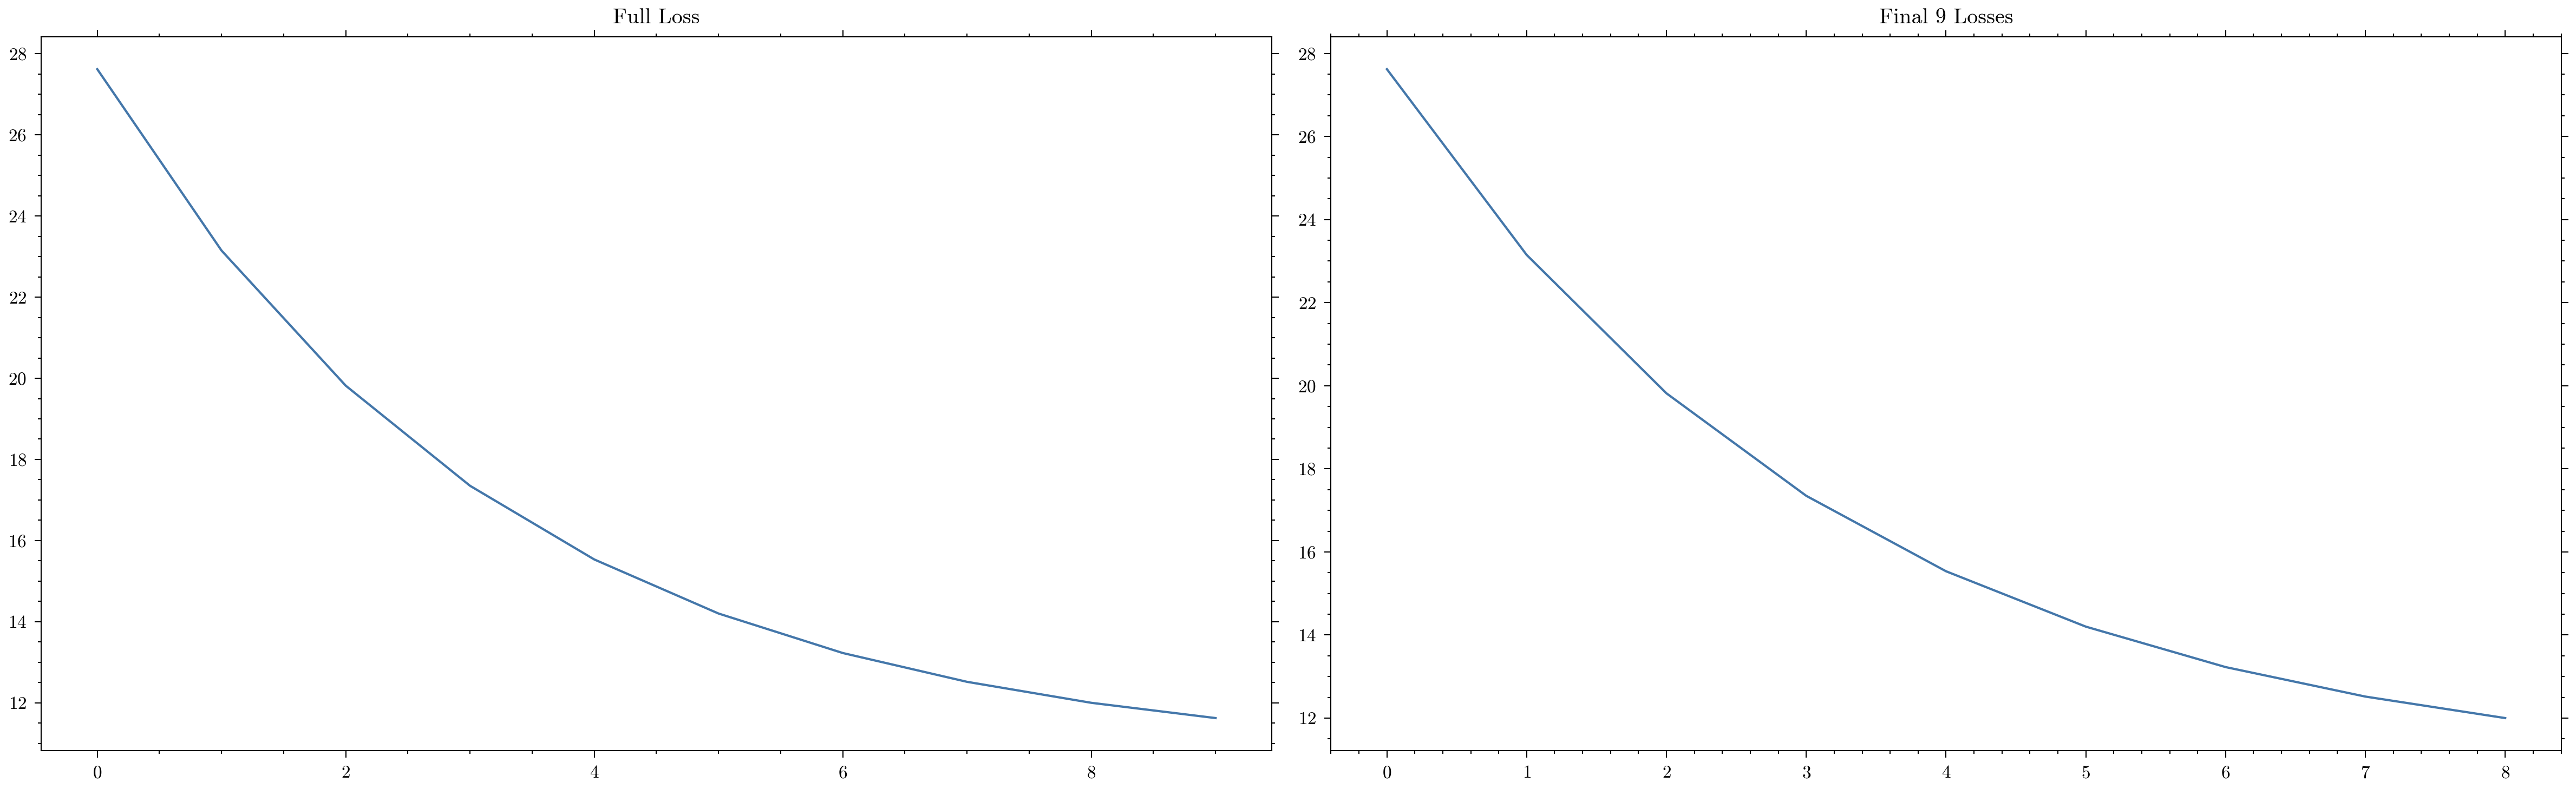

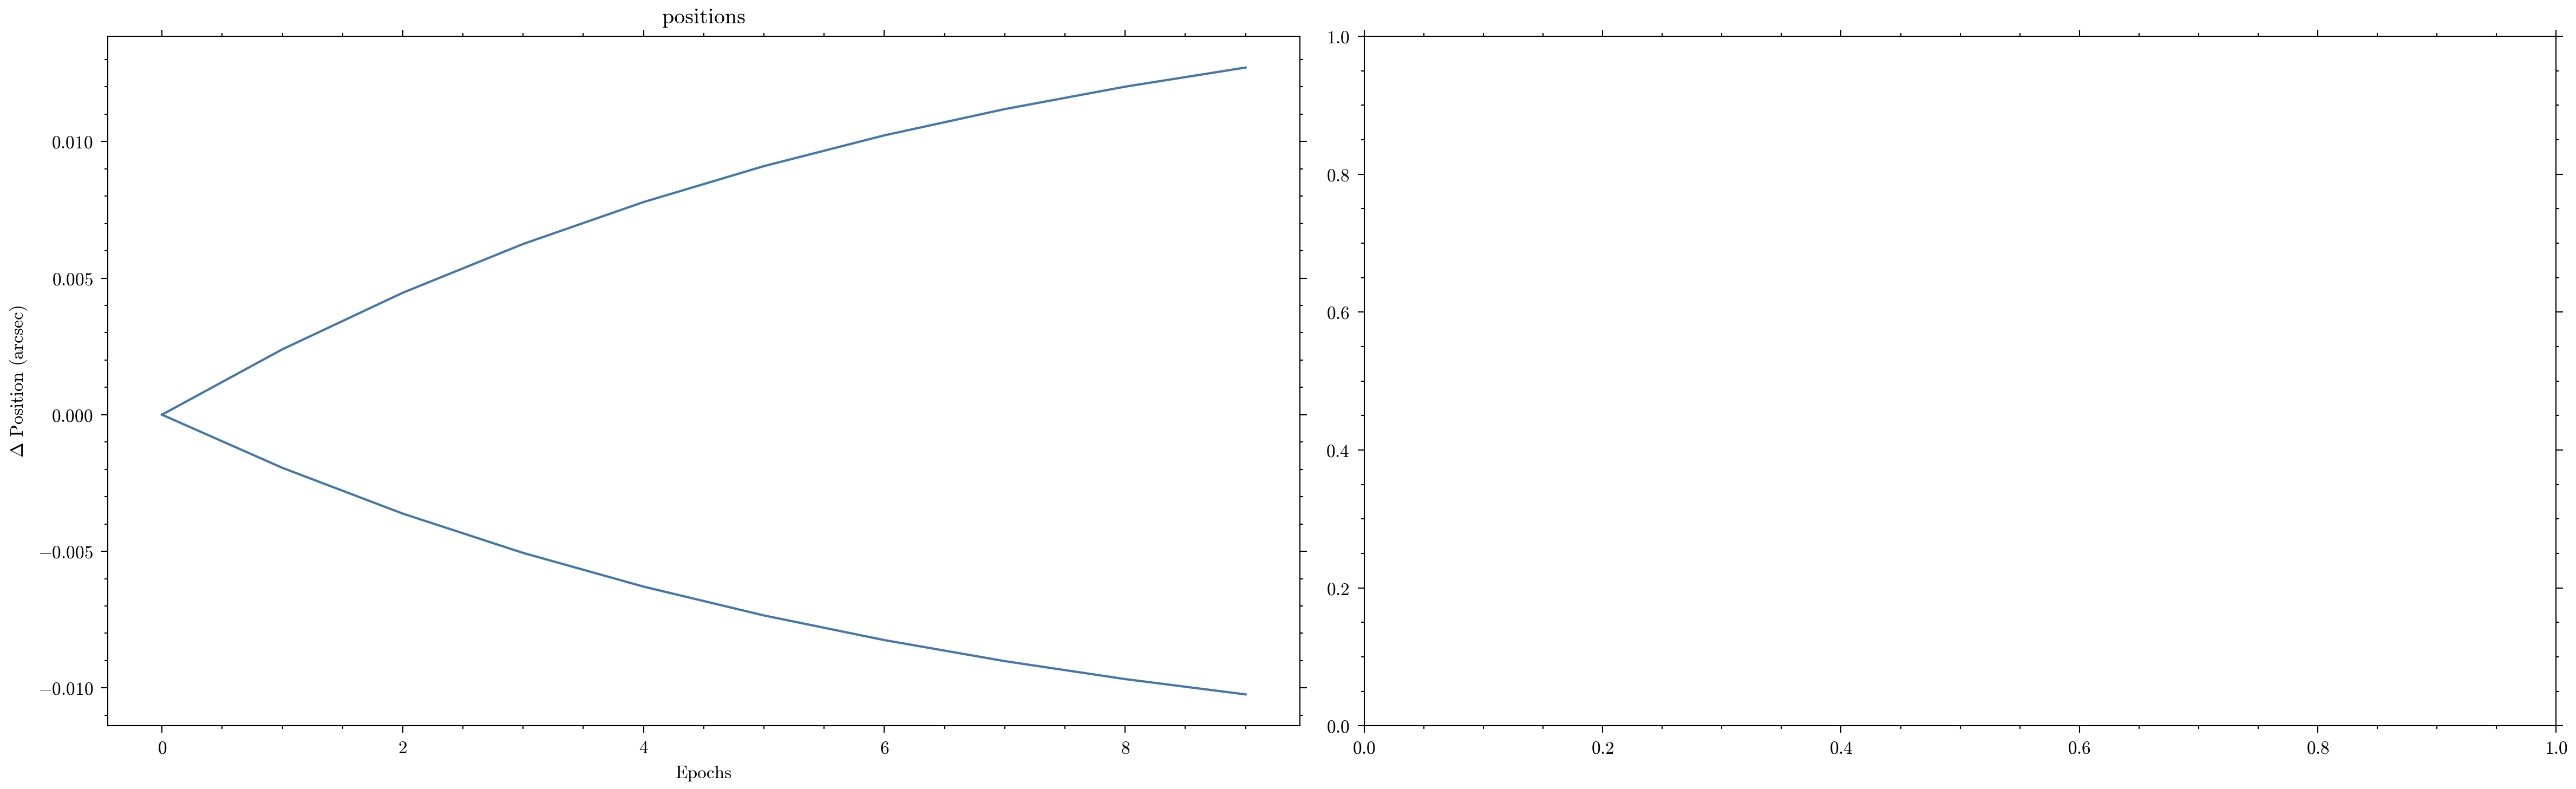

File 01373_023_02_03_1
Star HD 2236
Filter F430M
nints 8
ngroups 12



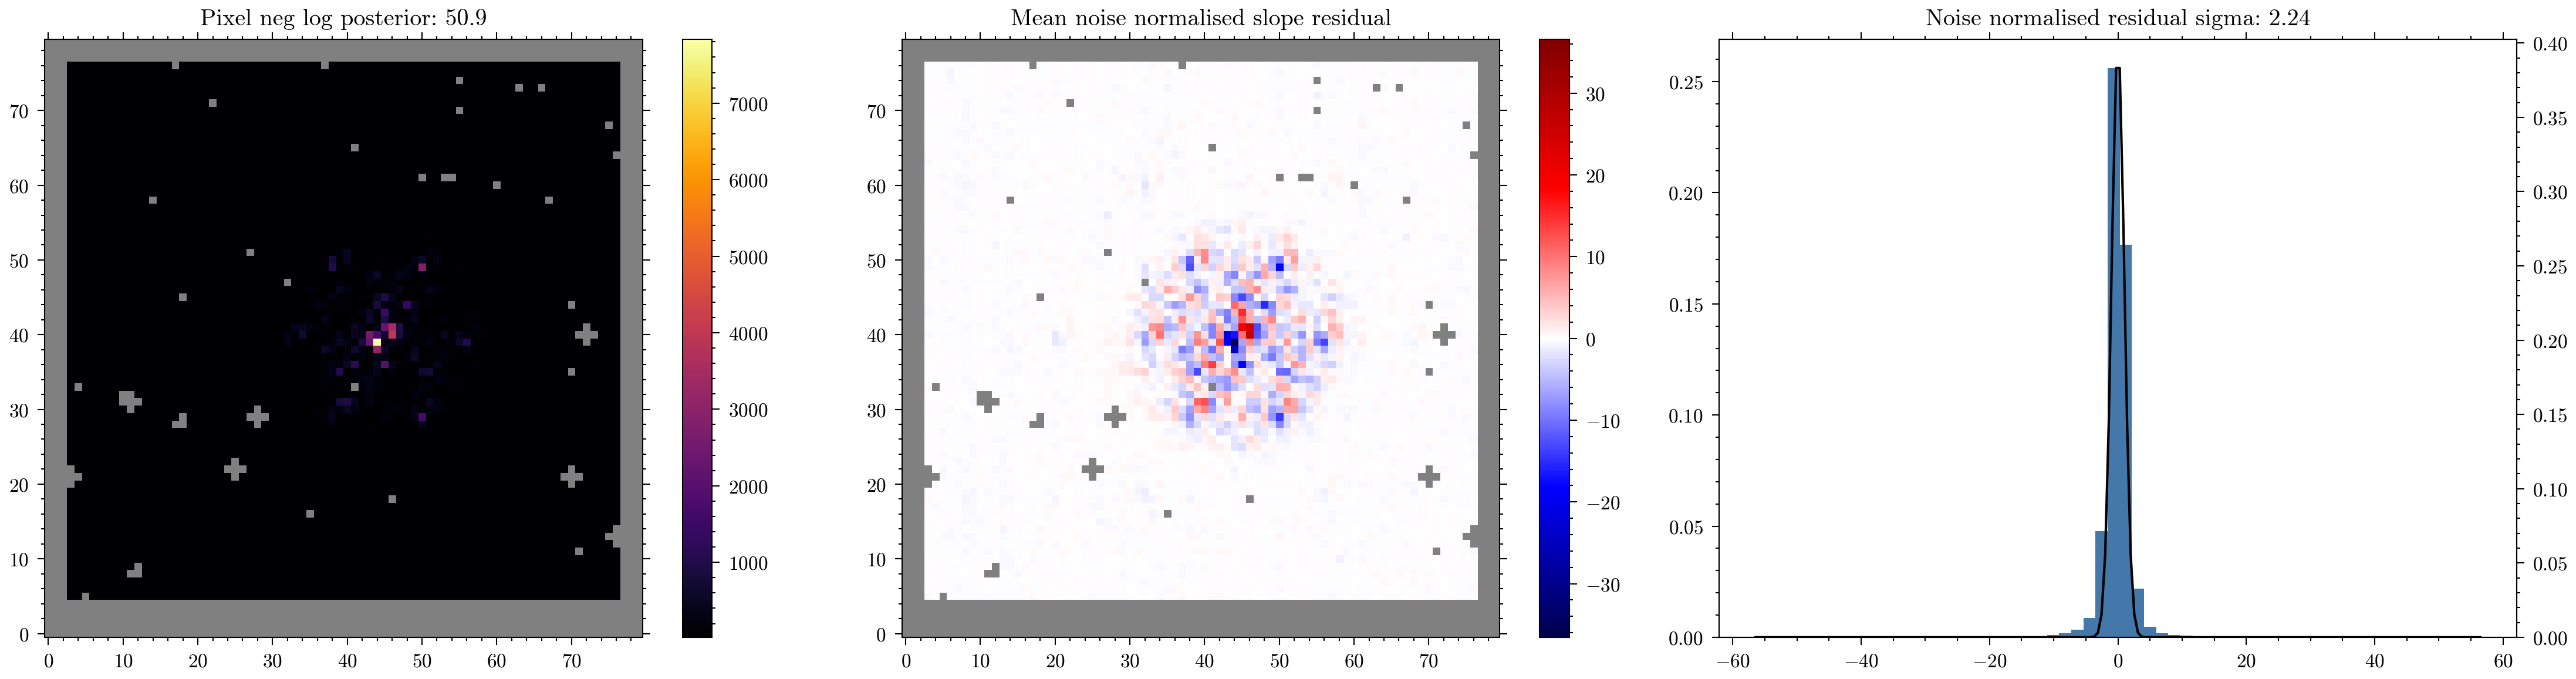

In [11]:
for exp in fits:
    summarise_reconstruction(model, fits, result=result)

import planetmapper
import scipy

features = {
    "seth": (132, -5.3),  # long [deg], lat [deg]
    # "masubi": (--56.18, -49.6),
    "P197": (108.8, -47.3),
    "masubi": (52.6, -45),
    "leizi": (44.93, 13.48),
    # "leizi": (-315.074, 13.48),
    "amirani": (115.2, 24.0),
    # "subobs": (--107.57361768, 2.60587485),
}
# https://iopscience.iop.org/article/10.3847/PSJ/ad4346/pdf


def plot_io_with_ephemeris(
    ax,
    array,
    exp,
    data_dir,
    pixel_scale,
    roll_angle_degrees=0.00,
    legend=False,
    points=None,
    **kwargs
):

    body = planetmapper.Observation(data_dir + exp.filename + "_uncal.fits")
    if points is not None:
        body.coordinates_of_interest_lonlat = points

    def coordinate_func(ra, dec):
        x, y = body.radec2angular(ra, dec)
        return -x, y

    body.plot_wireframe_custom(
        # body.plot_wireframe_angular(
        ax,
        coordinate_func=coordinate_func,
        # aspect_adjustable="box",
        add_title=False,
        label_poles=True,
        indicate_equator=True,
        indicate_prime_meridian=True,
        grid_interval=30,
        grid_lat_limit=75,
        formatting={
            # "limb": {
            #     "linestyle": "--",
            #     "linewidth": 0.8,
            #     "alpha": 0.8,
            #     "color": "white",
            # },
            "grid": {
                "linestyle": "--",
                "linewidth": 0.5,
                "alpha": 0.3,
                "color": "k",
            },
            "equator": {
                "color": "r",
                "linewidth": 1,
                "color": "r",
                "label": "equator",
                # "alpha": 0.0,
            },
            "terminator": {
                "linewidth": 1,
                "linestyle": "-",
                "color": "aqua",
                "alpha": 0.0,
                "label": "terminator",
            },
            "coordinate_of_interest_lonlat": {
                "color": "gold",
                "marker": "^",
                "facecolors": "none",
                # "markeredgecolor": "red",
                "s": 10,
                "label": "volcano",
            },
            "limb_illuminated": {"color": "b", "alpha": 0.0},
        },
    )

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper left",
        )

    im = plot_result(
        ax,
        array,
        pixel_scale=pixel_scale,
        roll_angle_degrees=roll_angle_degrees,
        show_diff_lim=True,
        **kwargs,
    )

    return im


def plot_result(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = 0.0,
    model=None,
    show_diff_lim: bool = True,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    vmin: float = 0.0,
    vmax: float = None,
    power=0.5,
    contour=False,
    scale=1.0,
    translate=(0.0, 0.0),
):
    rotation_transform = (
        mpl.transforms.Affine2D()
        .translate(*translate)
        .rotate_deg(roll_angle_degrees)
        .scale(scale)
    )  # Create a rotation transformation

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=[0.5, 0, -0.5],
        yticks=[-0.5, 0, 0.5],
        **axis_labels,
    )  # Set the axis labels
    if model is not None:
        pixel_scale = model.psf_pixel_scale / model.optics.oversample / scale
        if show_diff_lim:
            ax = dorito.plotting.plot_diffraction_limit(model, ax, OOP=True)

    kwargs = {
        "cmap": cmap,
        "extent": dorito.plotting.get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": mpl.colors.PowerNorm(power, vmin=vmin, vmax=vmax),
        "aspect": "equal",
    }
    if contour:
        im = ax.contour(
            array,
            linewidths=0.5,
            levels=array.max() * np.linspace(0, 1, 10) ** 2,
            **kwargs,
        )
    else:
        im = ax.imshow(
            array,
            # interpolation="bilinear",
            **kwargs,
        )

    ax.axis("equal")
    trans_data = rotation_transform + ax.transData  # creating transformation
    im.set_transform(trans_data)  # applying transformation to image

    return im


def compute_com_physical(array, pixel_scale):
    """
    Compute the center of mass of a 2D array, assuming the center of the array is at (0, 0).

    Parameters:
    - array: 2D numpy array representing the mass distribution.
    - pixel_scale: The physical scale of each pixel (e.g., in units per pixel).

    Returns:
    - com_physical: The center of mass in physical coordinates, assuming (0, 0) at the center of the array.
    """
    # Compute the center of mass in pixel indices
    com_index = np.array(scipy.ndimage.center_of_mass(numpy.array(array)))

    # Calculate the center of the array in pixel indices
    array_center = np.array(array.shape) / 2 - 0.5  # (rows/2 - 0.5, cols/2 - 0.5)

    # Convert to physical coordinates
    com_physical = (com_index - array_center) * pixel_scale

    return np.array(
        [-com_physical[1], com_physical[0]]
    )  # Return (x, y) in physical coordinates

In [9]:
# from planetmapper.kernel_downloader import download_urls

# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/")
# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/")
# download_urls(
#     "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp"
# )
# download_urls("https://naif.jpl.nasa.gov/pub/naif/JWST/kernels/spk/")


result_model = result.model


io_peak_flux = np.array([result_model.get_distribution(exp) for exp in sci_fits]).max()
clip_value = 0.001

save_dir = "gifs/spinning_io/"
for exp, file in zip(sci_fits, sci_files):

    dist = result_model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd").isot
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.5))
    c0 = plot_result(
        ax[0],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-rolls[exp.filename[:-4]],
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        ax[1],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-rolls[exp.filename[:-4]],
        scale=source_size / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    eps = 3e-2
    for i, (x, y) in enumerate(coords):  # i should now correctly track the index
        ax[1].text(
            x - eps,
            y,
            f"{i+1}",
            fontsize=7,
            c="gold",
            fontfamily="monospace",
            fontweight="bold",
        )  # Use i in the label

    fig.colorbar(c0)
    ax[0].set_title(f"Io: {time}")
    ax[1].set_title(f"Ephemeris")
    plt.tight_layout()
    fig.colorbar(c1, ax=ax[1])
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

AttributeError: AmigoModel has no attribute get_distribution.

In [ ]:
# formats = [
#     "jd",
#     "mjd",
#     "decimalyear",
#     "unix",
#     "unix_tai",
#     "cxcsec",
#     "gps",
#     "plot_date",
#     "stardate",
#     "datetime",
#     "ymdhms",
#     "iso",
#     "isot",
#     "yday",
#     "datetime64",
#     "fits",
#     "byear",
#     "jyear",
#     "byear_str",
#     "jyear_str",
# ]

# time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")

# list(time.ymdhms)[-3:]


# def convert_time(time):

#     if type(time) == str:
#         time = astropy.time.Time(str(time, format="mjd"))

#     t = list(time.ymdhms)[-3:]

#     return f"{t[0]:02d}h {t[1]:02d}m {t[2]:.0f}s"


# # convert_time(rang[0])

In [ ]:
def get_exposing(files, eps=1e0, samples=1e4):

    starts = []
    ends = []
    for file in files:

        # print(file[0].header)
        start = astropy.time.Time(file[0].header["EXPSTART"], format="mjd")
        end = astropy.time.Time(file[0].header["EXPEND"], format="mjd")

        starts.append(mins_past_the_hour(start.mjd))
        ends.append(mins_past_the_hour(end.mjd))

    starts = np.array(starts)
    ends = np.array(ends)
    rang = np.linspace(starts.min() - eps, ends.max() + eps, int(samples))

    exposings = np.array(
        [
            np.where(rang > start, 1.0, 0.0) * np.where(rang < end, 1.0, 0.0)
            for start, end in zip(starts, ends)
        ]
    )

    return rang, exposings


def mins_past_the_hour(mjd):
    # Reference time: 5:00 PM (17:00) on August 1st, 2022 UTC
    ref_time = astropy.time.Time("2022-08-01 16:00:00", format="iso", scale="utc")

    # Convert input MJD to an astropy Time object
    current_time = astropy.time.Time(mjd, format="mjd", scale="utc")

    # Compute time difference in minutes
    delta_minutes = (current_time - ref_time).to("min").value

    return delta_minutes

In [ ]:
%matplotlib inline

rang, exposings = get_exposing(sci_files, eps=1.35)
exposing = np.sum(exposings, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(6, 3), gridspec_kw={"hspace": 0.0, "wspace": 0.0, "left":0, "right":1.})

# Adjust layout first
plt.tight_layout()

fig.subplots_adjust(bottom=0.1)  # Shift everything up to leave space for time axis

# Create a new axes for the time plot — [left, bottom, width, height] in figure fraction
time_ax = fig.add_axes([0., 0.0, 1., .1])  # Tune values if needed

for col, exp, file in zip(range(len(sci_fits)), sci_fits, sci_files):

    axes[0][col].axis("off")
    axes[1][col].axis("off")

    dist = result_model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    # axes[0][col].set(title=convert_time(time))

    c0 = plot_result(
        axes[0][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-rolls[exp.filename],
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        axes[1][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-rolls[exp.filename],
        scale=source_size / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    # eps = 3e-2
    # for i, (x, y) in enumerate(coords):  # i should now correctly track the index
    #     axes[1][col].text(
    #         x - eps,
    #         y,
    #         f"{i+1}",
    #         fontsize=7,
    #         c="gold",
    #         fontfamily="monospace",
    #         fontweight="bold",
    #     )  # Use i in the label

time_ax.plot(rang, exposing, 'k')
time_ax.fill_between(rang, exposing, color='k', alpha=0.2)
time_ax.spines['top'].set_visible(False)
time_ax.spines['right'].set_visible(False)
time_ax.spines['left'].set_visible(False)
time_ax.tick_params(axis="x", which="both", top=False)
time_ax.set(
    xlim=(rang.min(), rang.max()),
    xlabel="Time of day on Aug 1st 2022 [UTC]",  # Set the x-axis label
    xticks=range(35, 75, 5),
    xticklabels=["16:35", "16:40", "16:45", "16:50", "16:55", "17:00", "17:05", "17:10"],
    yticks=[],
    )


    # time_ax.axis("off")

plt.show()

# plt.show()

In [ ]:
def lcurve_sweep(
    regulariser: str,  # e.g. "L1", "L2", "TV", "QV", "ME", "SF"
    coeffs,
    reg_func_dict,
    trainer,
    model,
    optimisers,
    epochs,
    exposures,
):
    """
    Function to find an optimal regularisation hyperparameter using the l-curve method.
    """

    @zdx.filter_jit
    def calc_balance(model, exposures, args, coeff):
        return np.array(
            [
                dorito.stats.prior_data_balance(model, exp, args, coeff)
                for exp in exposures
            ]
        ).sum(0)

    balances = []
    results = []

    args = {"reg_dict": {regulariser: None}, "reg_func_dict": reg_func_dict}

    for coeff in coeffs:
        print(f"Regulariser: {regulariser}, Coefficient: {coeff:.2e}")

        args["reg_dict"][regulariser] = coeff

        result = trainer.train(
            model=model,
            optimisers=optimisers,
            epochs=epochs,
            batches=exposures,
            args=args,
        )

        balance = calc_balance(result.model, exposures, args, coeff)
        balances.append(balance)

        results.append(result)

    return results, np.array(balances).T

In [ ]:
coeffs = 10 ** np.arange(-6.0, -2.5, 0.5)

results, balances = lcurve_sweep(
    "L1",
    coeffs,
    {"L1": L1_REG},
    trainer=trainer,
    model=model,
    optimisers=config,
    epochs=500,
    exposures=fits,
)

for res, coeff in zip(results, coeffs):
    print(f"{coeff:.2e}")
    summarise_reconstruction(res.model, fits, result=res)

In [ ]:
# for res, coeff in zip(results, coeffs):
#     print(f"{coeff:.2e}")
#     summarise_reconstruction(res.model, fits, result=res)

In [ ]:
def plot_lcurve(balances, coeffs, regulariser):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    sc = ax.scatter(
        balances[0],
        balances[1] / coeffs,
        # linestyle="--",
        # marker="o",
        s=3,
        c=coeffs,
        norm=mpl.colors.LogNorm(),
        cmap="tab20",
    )
    ax.set(
        xscale="log",
        yscale="log",
        xlabel="Data Likelihood",
        ylabel="Prior Likelihood",
        title=f"L-curve: {regulariser}",
    )
    plt.colorbar(
        sc,
        label=r"Regularisation Coefficient $\lambda$",
        ticks=10.0 ** np.arange(-10, 15, 1),
    )
    plt.tight_layout()
    plt.show()


plot_lcurve(balances, coeffs, "L1 on wavelets")

In [ ]:
for r, c in zip(results, coeffs):

    ticks = [-0.5, 0, 0.5]
    exp = sci_fits[0]

    try:
        dist = r.model.get_distribution(exp)
    except:
        dist = exp.get_distribution(r.model)

    fig, ax = plt.subplots(figsize=(3, 2))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=pscale(model),
        roll_angle_degrees=-rolls[exp.filename],
        cmap="afmhot_u",
        power=0.3,
        vmin=0,
        ticks=ticks,
    )
    # print(b)
    ax.set(title=f"{c:.2e}")
    ax.axis("off")
    plt.show()